In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

OUT = Path("output")
OUT.mkdir(exist_ok=True)


In [2]:
DATA_PATH = "gjsynthetic_bank_fraud_30k.csv"
FEATURES_PATH = OUT / "feature_columns.json"
CAT_COLS_PATH = OUT / "cat_columns.json"
MEDIANS_PATH = OUT / "num_medians.json"
METRICS_PATH = OUT / "metrics.json"
MODEL_PATH = OUT / "fraud_model.joblib"
SCORDED_PATH = OUT / "scored_data.csv"
CM_PATH = OUT / "confusion_matrix.png"


def generate_synthetic_data(n=30000, seed=42):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 80, n)
    gender = rng.choice(["Male", "Female", "Other"], n, p=[0.49, 0.49, 0.02])
    marital = rng.choice(["Single", "Married", "Divorced"], n, p=[0.38, 0.54, 0.08])
    education = rng.choice(["High School", "Associate", "Bachelor", "Master", "PhD"], n, p=[0.18, 0.20, 0.37, 0.19, 0.06])
    employment = rng.choice(["Salaried", "Self-employed", "Contract", "Unemployed"], n, p=[0.56, 0.18, 0.18, 0.08])
    region = rng.choice(["North", "South", "East", "West", "Central"], n, p=[0.23, 0.22, 0.19, 0.21, 0.15])
    tenure = np.clip(np.round(rng.gamma(2.0, 3.0, n), 1), 0, 35)
    annual_income = np.clip(rng.lognormal(mean=11.0, sigma=0.55, size=n), 150000, 5000000).round(0)
    employment_years = np.minimum(tenure, np.clip(np.round(rng.gamma(2.3, 3.0, n), 0), 0, 40))
    savings_balance = np.clip(rng.lognormal(mean=10.2, sigma=0.9, size=n), 0, 3000000).round(0)
    monthly_expenses = np.clip((annual_income / 12) * rng.uniform(0.35, 0.95, n), 5000, None).round(0)
    existing_loans = rng.integers(0, 6, n)
    num_delinquencies = rng.choice([0, 1, 2, 3, 4, 5], n, p=[0.72, 0.13, 0.08, 0.04, 0.02, 0.01])
    recent_credit_inquiries = rng.choice([0, 1, 2, 3, 4, 5, 6], n, p=[0.22, 0.21, 0.19, 0.14, 0.10, 0.08, 0.06])
    loan_amount = np.clip(rng.lognormal(mean=10.0, sigma=0.7, size=n), 5000, 1500000).round(0)
    credit_score = np.clip(
        820 - age * 1.0 - num_delinquencies * 42 - recent_credit_inquiries * 7
        - (loan_amount / np.maximum(annual_income, 1)) * 110
        + np.where(employment == "Salaried", 10, 0)
        + np.where(np.isin(education, ["Master", "PhD"]), 8, 0)
        + rng.normal(0, 28, n),
        300, 850
    ).round(0)
    dti = np.clip((loan_amount / np.maximum(annual_income, 1)) * 0.85 + monthly_expenses / np.maximum(annual_income, 1) * 0.35 + rng.normal(0, 0.03, n), 0.01, 0.95).round(3)
    kyc_verified = np.where((credit_score > 620) & (savings_balance > 5000) & (age >= 21), 1, rng.choice([0, 1], n, p=[0.35, 0.65]))
    document_match_score = np.clip(rng.normal(0.9, 0.08, n) - (1 - kyc_verified) * 0.25, 0, 1).round(3)
    face_match_score = np.clip(rng.normal(0.92, 0.07, n) - (1 - kyc_verified) * 0.30, 0, 1).round(3)
    liveness_score = np.clip(rng.normal(0.93, 0.06, n) - (1 - kyc_verified) * 0.32, 0, 1).round(3)
    device_trust_score = np.clip(rng.normal(0.82, 0.12, n) - (1 - kyc_verified) * 0.20, 0, 1).round(3)
    transaction_velocity = np.clip(rng.gamma(2.0, 3.0, n), 0, 30).round(2)
    avg_txn_amount = np.clip(rng.lognormal(mean=7.5, sigma=0.8, size=n), 500, 250000).round(0)
    cash_out_ratio = np.clip(rng.uniform(0, 1, n), 0, 1).round(3)
    account_age_months = np.clip(rng.gamma(2.2, 24.0, n), 1, 360).round(0)
    geo_risk_score = np.clip(rng.normal(0.25, 0.18, n), 0, 1).round(3)
    rule_engine_hits = np.clip((num_delinquencies > 0).astype(int) + (recent_credit_inquiries >= 4).astype(int) + (dti > 0.42).astype(int), 0, 3)

    fraud_score = (
        -3.6 + 0.013 * (650 - credit_score) + 0.9 * num_delinquencies + 0.45 * recent_credit_inquiries
        + 2.1 * dti + 0.8 * (1 - kyc_verified) + 0.9 * (1 - face_match_score) + 0.8 * (1 - liveness_score)
        + 0.7 * (1 - document_match_score) + 0.6 * (1 - device_trust_score) + 0.25 * geo_risk_score
        + 0.02 * transaction_velocity + 0.0000015 * loan_amount - 0.0000010 * annual_income + 0.12 * rule_engine_hits
        + rng.normal(0, 0.55, n)
    )
    fraud_probability = 1 / (1 + np.exp(-fraud_score))
    fraud_label = (fraud_probability >= np.quantile(fraud_probability, 0.84)).astype(int)

    return pd.DataFrame({
        "customer_id": [f"C{i:06d}" for i in range(n)],
        "age": age,
        "gender": gender,
        "marital_status": marital,
        "education_level": education,
        "employment_status": employment,
        "region": region,
        "customer_tenure_years": tenure,
        "annual_income": annual_income,
        "employment_years": employment_years,
        "savings_balance": savings_balance,
        "monthly_expenses": monthly_expenses,
        "existing_loans": existing_loans,
        "num_delinquencies": num_delinquencies,
        "recent_credit_inquiries": recent_credit_inquiries,
        "loan_amount": loan_amount,
        "credit_score": credit_score,
        "debt_to_income_ratio": dti,
        "kyc_verified": kyc_verified,
        "document_match_score": document_match_score,
        "face_match_score": face_match_score,
        "liveness_score": liveness_score,
        "device_trust_score": device_trust_score,
        "transaction_velocity": transaction_velocity,
        "avg_txn_amount": avg_txn_amount,
        "cash_out_ratio": cash_out_ratio,
        "account_age_months": account_age_months,
        "geo_risk_score": geo_risk_score,
        "rule_engine_hits": rule_engine_hits,
        "fraud_label": fraud_label,
    })

In [3]:
def preprocess_df(df):
    df = df.copy()
    if "customer_id" in df.columns:
        df = df.drop(columns=["customer_id"])
    target = df.pop("fraud_label")
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
    medians = df[num_cols].median(numeric_only=True).to_dict()
    for c, v in medians.items():
        df[c] = df[c].fillna(v)
    for c in cat_cols:
        mode = df[c].mode(dropna=True)
        df[c] = df[c].fillna(mode.iloc[0] if not mode.empty else "Unknown")
    dummies = pd.get_dummies(df, columns=cat_cols, drop_first=False)
    return dummies, target.astype(int), dummies.columns.tolist(), cat_cols, medians


In [4]:
if os.path.exists(DATA_PATH):
    raw = pd.read_csv(DATA_PATH)
else:
    raw = generate_synthetic_data(30000, 42)
    raw.to_csv(DATA_PATH, index=False)


In [5]:
X, y, feature_cols, cat_cols, medians = preprocess_df(raw)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=18, min_samples_leaf=4,
    class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
hgb = HistGradientBoostingClassifier(
    learning_rate=0.08, max_depth=8, max_iter=180, random_state=42
)

rf.fit(X_train, y_train)
hgb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.08
,max_iter,180
,max_leaf_nodes,31
,max_depth,8
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [6]:
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
hgb_pred = hgb.predict(X_test)
hgb_proba = hgb.predict_proba(X_test)[:, 1]

rf_metrics = {
    "accuracy": float(accuracy_score(y_test, rf_pred)),
    "precision": float(precision_score(y_test, rf_pred, zero_division=0)),
    "recall": float(recall_score(y_test, rf_pred, zero_division=0)),
    "f1": float(f1_score(y_test, rf_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, rf_proba)),
}
hgb_metrics = {
    "accuracy": float(accuracy_score(y_test, hgb_pred)),
    "precision": float(precision_score(y_test, hgb_pred, zero_division=0)),
    "recall": float(recall_score(y_test, hgb_pred, zero_division=0)),
    "f1": float(f1_score(y_test, hgb_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, hgb_proba)),
}

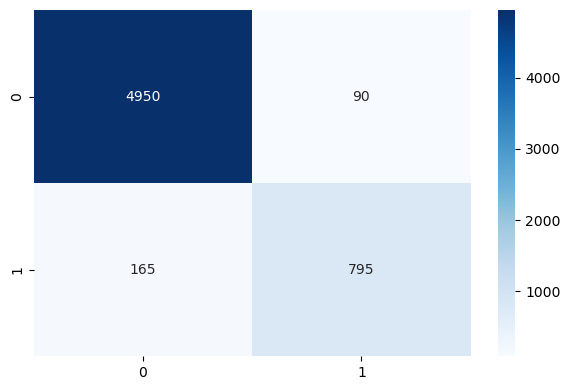

{'best_model': 'hist_gradient_boosting', 'accuracy': 0.9575, 'precision': 0.8983050847457628, 'recall': 0.828125, 'f1': 0.8617886178861789, 'roc_auc': 0.9879249338624339}


In [7]:
best_model = rf if rf_metrics["roc_auc"] >= hgb_metrics["roc_auc"] else hgb
best_name = "random_forest" if best_model is rf else "hist_gradient_boosting"
selected_metrics = rf_metrics if best_model is rf else hgb_metrics

joblib.dump(best_model, MODEL_PATH)
json.dump({"best_model": best_name, "rf_metrics": rf_metrics, "hgb_metrics": hgb_metrics, "selected_metrics": selected_metrics}, open(METRICS_PATH, "w"), indent=2)
json.dump(feature_cols, open(FEATURES_PATH, "w"), indent=2)
json.dump(cat_cols, open(CAT_COLS_PATH, "w"), indent=2)
json.dump(medians, open(MEDIANS_PATH, "w"), indent=2)

cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.tight_layout()
plt.show()

scored = raw.copy()
scored_x = pd.get_dummies(scored.drop(columns=["fraud_label", "customer_id"]), drop_first=False)
scored_x = scored_x.reindex(columns=feature_cols, fill_value=0)
scored["fraud_probability"] = best_model.predict_proba(scored_x)[:, 1]
scored.to_csv(SCORDED_PATH, index=False)

print({"best_model": best_name, **selected_metrics})